In [ ]:
# ============================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
# ============================================================
# CELL 2: UPLOAD AND LOAD IRIS DATASET
# ============================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df.head()

Saving IRIS.csv to IRIS.csv


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# ============================================================
# CELL 3: SEPARATE FEATURES AND TARGET
# ============================================================

X = df[
    [
        'sepal_length',
        'sepal_width',
        'petal_length',
        'petal_width'
    ]
].values

y_labels = df['species'].values

In [ ]:
# ============================================================
# CELL 4: CONVERT CLASS LABELS INTO NUMERICAL VALUES
# ============================================================

class_names = np.unique(y_labels)

class_to_number = {
    class_name: i
    for i, class_name in enumerate(class_names)
}

number_to_class = {
    i: class_name
    for class_name, i in class_to_number.items()
}

y = np.array([
    class_to_number[label]
    for label in y_labels
])

In [ ]:
# ============================================================
# CELL 5: NORMALIZE THE INPUT FEATURES
# ============================================================

mean = np.mean(X, axis=0)

std = np.std(X, axis=0)

X = (X - mean) / std

In [ ]:
# ============================================================
# CELL 6: MANUAL TRAIN-TEST SPLIT
# ============================================================

np.random.seed(42)

indices = np.arange(len(X))

np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split = int(0.80 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
# ============================================================
# CELL 7: ONE-HOT ENCODE THE TARGET VALUES
# ============================================================

def one_hot(y, number_of_classes):

    encoded = np.zeros(
        (len(y), number_of_classes)
    )

    encoded[
        np.arange(len(y)),
        y
    ] = 1

    return encoded


number_of_classes = len(class_names)

y_train_encoded = one_hot(
    y_train,
    number_of_classes
)

y_test_encoded = one_hot(
    y_test,
    number_of_classes
)

In [ ]:
# ============================================================
# CELL 8: DEFINE ANN ARCHITECTURE
# ============================================================

input_neurons = 4

hidden_neurons = 5

output_neurons = 3

In [ ]:
# ============================================================
# CELL 9: INITIALIZE WEIGHTS AND BIASES
# ============================================================

np.random.seed(42)

W1 = np.random.randn(
    input_neurons,
    hidden_neurons
) * 0.01

b1 = np.zeros(
    (1, hidden_neurons)
)

W2 = np.random.randn(
    hidden_neurons,
    output_neurons
) * 0.01

b2 = np.zeros(
    (1, output_neurons)
)

In [ ]:
# ============================================================
# CELL 10: DEFINE RELU ACTIVATION FUNCTION
# ============================================================

def relu(x):

    return np.maximum(
        0,
        x
    )

In [ ]:
# ============================================================
# CELL 11: DEFINE RELU DERIVATIVE
# ============================================================

def relu_derivative(x):

    return (x > 0).astype(float)

In [ ]:
# ============================================================
# CELL 12: DEFINE SOFTMAX ACTIVATION FUNCTION
# ============================================================

def softmax(x):

    exp_x = np.exp(
        x - np.max(
            x,
            axis=1,
            keepdims=True
        )
    )

    return exp_x / np.sum(
        exp_x,
        axis=1,
        keepdims=True
    )

In [ ]:
# ============================================================
# CELL 13: FORWARD PROPAGATION
# ============================================================

def forward(X):

    Z1 = np.dot(
        X,
        W1
    ) + b1

    A1 = relu(Z1)

    Z2 = np.dot(
        A1,
        W2
    ) + b2

    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

In [ ]:
# ============================================================
# CELL 14: DEFINE CROSS-ENTROPY LOSS FUNCTION
# ============================================================

def cross_entropy(y_true, y_pred):

    epsilon = 1e-10

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.sum(
        y_true * np.log(y_pred)
    )

    loss = loss / len(y_true)

    return loss

In [ ]:
# ============================================================
# CELL 15: BACKPROPAGATION AND WEIGHT UPDATE
# ============================================================

def backward(
    X,
    y_true,
    Z1,
    A1,
    A2,
    learning_rate
):

    global W1, b1, W2, b2

    m = len(X)

    # Output layer gradient
    dZ2 = A2 - y_true

    dW2 = np.dot(
        A1.T,
        dZ2
    ) / m

    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    ) / m

    # Hidden layer gradient
    dA1 = np.dot(
        dZ2,
        W2.T
    )

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(
        X.T,
        dZ1
    ) / m

    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    ) / m

    # Update weights and biases
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

In [ ]:
# ============================================================
# CELL 16: TRAIN THE ANN USING GRADIENT DESCENT
# ============================================================

epochs = 1000

learning_rate = 0.01

loss_history = []

for epoch in range(epochs):

    # Forward propagation
    Z1, A1, Z2, A2 = forward(X_train)

    # Calculate loss
    loss = cross_entropy(
        y_train_encoded,
        A2
    )

    loss_history.append(loss)

    # Backpropagation
    backward(
        X_train,
        y_train_encoded,
        Z1,
        A1,
        A2,
        learning_rate
    )

In [ ]:
# ============================================================
# CELL 17: DEFINE PREDICTION FUNCTION
# ============================================================

def predict(X):

    _, _, _, probabilities = forward(X)

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    return predictions

In [ ]:
# ============================================================
# CELL 18: MAKE PREDICTIONS ON TEST DATA
# ============================================================

y_pred = predict(X_test)

In [ ]:
# ============================================================
# CELL 19: CALCULATE ACCURACY MANUALLY
# ============================================================

correct_predictions = np.sum(
    y_pred == y_test
)

total_predictions = len(y_test)

accuracy = (
    correct_predictions /
    total_predictions
)

accuracy_percentage = accuracy * 100

In [ ]:
# ============================================================
# CELL 20: CREATE CONFUSION MATRIX MANUALLY
# ============================================================

confusion_matrix = np.zeros(
    (
        number_of_classes,
        number_of_classes
    ),
    dtype=int
)

for actual, predicted in zip(
    y_test,
    y_pred
):

    confusion_matrix[
        actual,
        predicted
    ] += 1

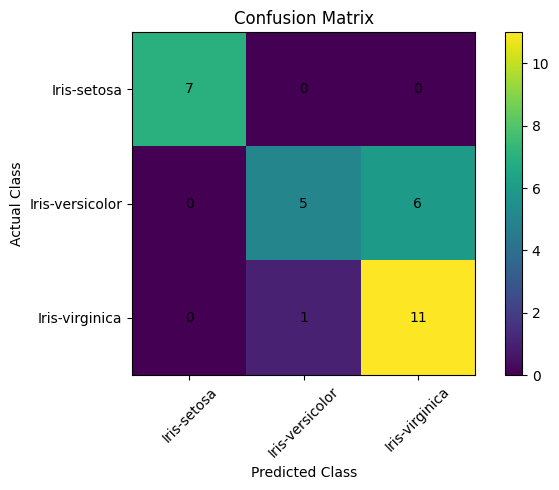

In [ ]:
# ============================================================
# CELL 21: PLOT CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.imshow(
    confusion_matrix
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    range(number_of_classes),
    class_names,
    rotation=45
)

plt.yticks(
    range(number_of_classes),
    class_names
)

for i in range(number_of_classes):

    for j in range(number_of_classes):

        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

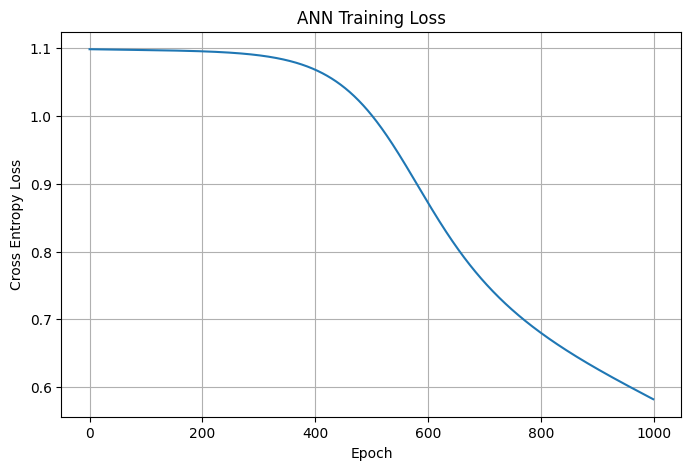

In [ ]:
# ============================================================
# CELL 22: PLOT TRAINING LOSS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    loss_history
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Cross Entropy Loss"
)

plt.title(
    "ANN Training Loss"
)

plt.grid()

plt.show()

In [ ]:
# ============================================================
# CELL 23: PREDICT A NEW IRIS FLOWER
# ============================================================

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

new_flower = (
    new_flower - mean
) / std

prediction = predict(
    new_flower
)

predicted_class = number_to_class[
    prediction[0]
]

predicted_class

'Iris-setosa'

In [ ]:
# ============================================================
# CELL 24: DISPLAY MODEL RESULTS
# ============================================================

print("Accuracy:", accuracy)

print("Accuracy (%):", accuracy_percentage)

print("Confusion Matrix:")
print(confusion_matrix)

print("Actual Classes:")
print(y_test)

print("Predicted Classes:")
print(y_pred)

print("New Flower Prediction:")
print(predicted_class)

Accuracy: 0.7666666666666667
Accuracy (%): 76.66666666666667
Confusion Matrix:
[[ 7  0  0]
 [ 0  5  6]
 [ 0  1 11]]
Actual Classes:
[1 0 1 1 0 1 2 2 0 1 2 2 0 2 0 1 2 2 1 2 1 1 2 2 0 1 2 0 1 2]
Predicted Classes:
[2 0 2 1 0 1 2 2 0 1 2 2 0 2 0 2 2 2 1 2 2 2 2 2 0 2 1 0 1 2]
New Flower Prediction:
Iris-setosa
